In [1]:
import pandas as pd
 
df = pd.read_csv('Meteo data.csv', sep=';', decimal='.')
df


,Station code,Station name,Year,Month,Day,Average daily temperature,Average daily relative humidity,Average daily wind speed [m/s],Average daily cloud cover [oktas]
0,252200150,WARSZAWA-BIELANY,2020,1,1,2.4,89.5,5.0,8.0
1,252200150,WARSZAWA-BIELANY,2020,1,2,1.3,77.5,3.3,7.0
2,252200150,WARSZAWA-BIELANY,2020,1,3,2.3,75.3,3.7,5.3
3,252200150,WARSZAWA-BIELANY,2020,1,4,3.3,84.0,5.0,6.7
4,252200150,WARSZAWA-BIELANY,2020,1,5,0.7,79.5,3.3,0.7
...,...,...,...,...,...,...,...,...,...
361,252200150,WARSZAWA-BIELANY,2020,12,27,-0.8,76.3,5.0,1.0
362,252200150,WARSZAWA-BIELANY,2020,12,28,4.0,82.0,5.7,7.3
363,252200150,WARSZAWA-BIELANY,2020,12,29,6.0,79.3,3.7,5.3
364,252200150,WARSZAWA-BIELANY,2020,12,30,4.4,92.5,1.3,8.0


In [2]:
df["Average daily cloud cover [oktas]"].describe()

count    366.000000
mean       4.995082
std        2.393365
min        0.000000
25%        3.000000
50%        5.300000
75%        7.300000
max        8.000000
Name: Average daily cloud cover [oktas], dtype: float64

In [3]:
# A list containing the starting days for the months
months_change = [0, 31, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
# A list containing the names of the months
months_names = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']
# Dataset containing 12 values: average for monthly measurements
df_month_avg = df.groupby('Month')[[
        'Average daily temperature', 'Average daily relative humidity',
        'Average daily wind speed [m/s]', 'Average daily cloud cover [oktas]'
]].mean()
 
df_month_avg.columns = [
        'Average temperature', 'Average relative humidity',
        'Average wind speed [m/s]', 'Average total cloud cover [oktas]'
]

df_month_avg

,Average temperature,Average relative humidity,Average wind speed [m/s],Average total cloud cover [oktas]
Month,,,,
1,2.890323,84.838710,3.374194,6.145161
2,4.293103,78.124138,3.417241,5.606897
3,5.067742,61.983871,2.967742,4.503226
4,9.570000,50.206667,2.870000,2.953333
5,12.109677,65.329032,2.580645,4.912903
6,19.093333,75.943333,2.196667,5.073333
7,19.635484,68.054839,2.225806,4.283871
8,20.170968,69.087097,1.912903,3.948387
9,15.543333,77.610000,2.173333,3.860000


In [5]:
df["Average daily cloud cover [oktas]"] < 4

0      False
1      False
2      False
3      False
4       True
       ...  
361     True
362    False
363    False
364    False
365    False
Name: Average daily cloud cover [oktas], Length: 366, dtype: bool

In [6]:
# -------------------------
# 3. DEFINICIJA USLOVA
# -------------------------
# "nice day" = mala oblačnost
nice = df[df["Average daily cloud cover [oktas]"] < 4]
bad = df[df["Average daily cloud cover [oktas]"] >= 4]

In [7]:
nice.groupby("Month").size()

Month
1      5
2      7
3     14
4     22
5     12
6      9
7     11
8     16
9     14
10     7
11     4
12     6
dtype: int64

In [8]:
# -------------------------
# 4. BROJANJE PO MESECIMA
# -------------------------
s_nice_days_per_month = nice.groupby("Month").size().reindex(range(1, 13), fill_value=0)
s_bad_days_per_month = bad.groupby("Month").size().reindex(range(1, 13), fill_value=0)
s_nice_days_per_month,s_bad_days_per_month

(Month
 1      5
 2      7
 3     14
 4     22
 5     12
 6      9
 7     11
 8     16
 9     14
 10     7
 11     4
 12     6
 dtype: int64,
 Month
 1     26
 2     22
 3     17
 4      8
 5     19
 6     21
 7     20
 8     15
 9     16
 10    24
 11    26
 12    25
 dtype: int64)

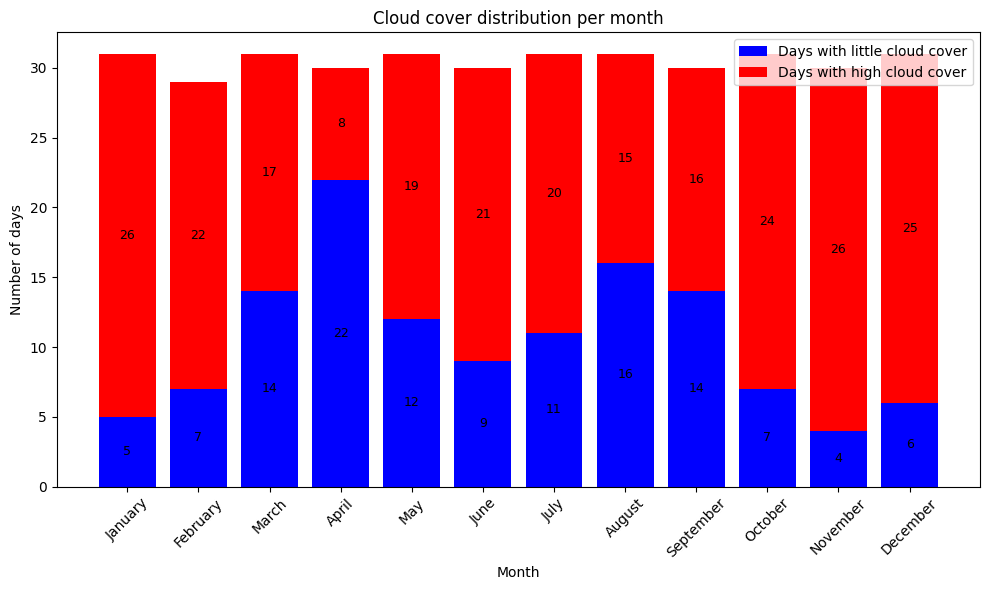

In [9]:
# -------------------------
# 5. PLOT
# -------------------------
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

plt.bar(range(1, 13),
        s_nice_days_per_month,
        color='blue',
        label="Days with little cloud cover")

plt.bar(range(1, 13),
        s_bad_days_per_month,
        bottom=s_nice_days_per_month,
        color='red',
        label="Days with high cloud cover")

plt.xticks(range(1, 13), months_names, rotation=45)
plt.ylabel("Number of days")
plt.xlabel("Month")
plt.title("Cloud cover distribution per month")
plt.legend()

# -------------------------
# 6. ANNOTACIJE
# -------------------------
for i in range(12):
    plt.text(i + 1,
             s_nice_days_per_month.iloc[i] / 2,
             str(s_nice_days_per_month.iloc[i]),
             ha='center', va='center', fontsize=9)

    plt.text(i + 1,
             s_nice_days_per_month.iloc[i] + s_bad_days_per_month.iloc[i] / 2,
             str(s_bad_days_per_month.iloc[i]),
             ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.show()

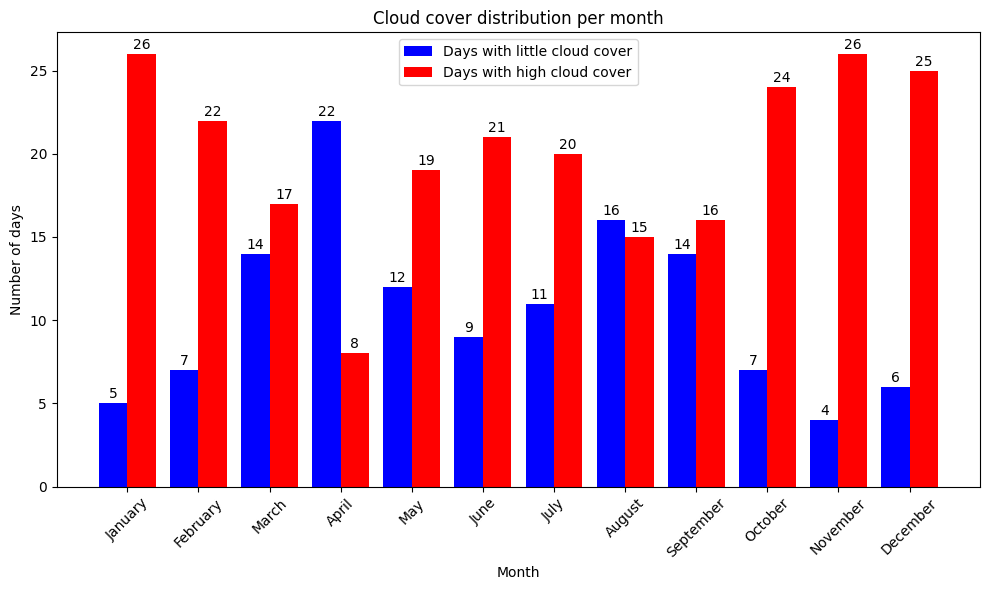

In [10]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

x = np.arange(12)      # pozicije meseci: 0..11
width = 0.4            # širina stuba

plt.bar(
    x - width/2,
    s_nice_days_per_month,
    width=width,
    color='blue',
    label='Days with little cloud cover'
)

plt.bar(
    x + width/2,
    s_bad_days_per_month,
    width=width,
    color='red',
    label='Days with high cloud cover'
)

plt.xticks(x, months_names, rotation=45)

plt.ylabel("Number of days")
plt.xlabel("Month")
plt.title("Cloud cover distribution per month")
plt.legend()

# -------------------------
# ANNOTACIJE
# -------------------------

for i in range(12):

    plt.text(
        x[i] - width/2,
        s_nice_days_per_month.iloc[i] + 0.3,
        str(s_nice_days_per_month.iloc[i]),
        ha='center'
    )

    plt.text(
        x[i] + width/2,
        s_bad_days_per_month.iloc[i] + 0.3,
        str(s_bad_days_per_month.iloc[i]),
        ha='center'
    )

plt.tight_layout()
plt.show()

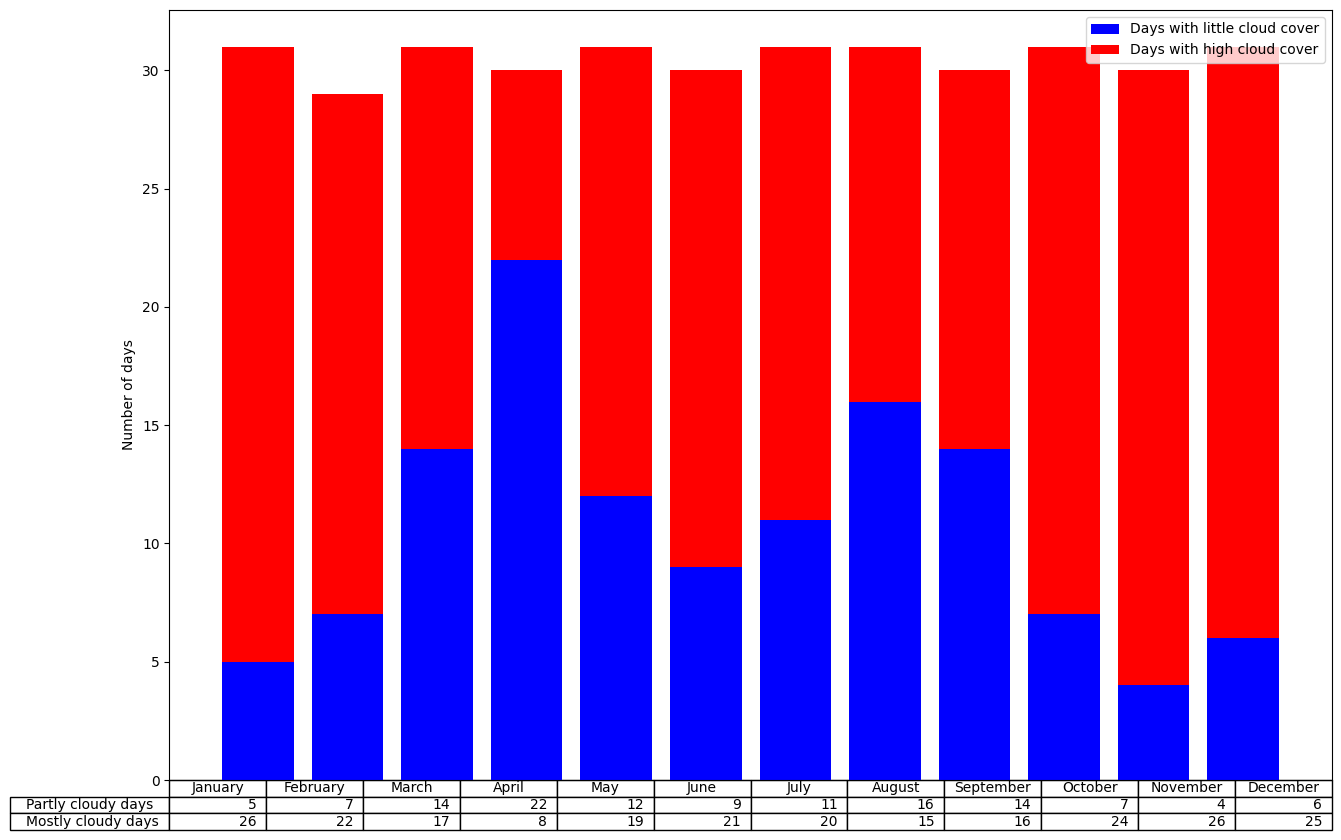

In [11]:
plt.figure(figsize=(15,10))
plt.bar(range(1, 13), s_nice_days_per_month, color='blue', label="Days with little cloud cover")
plt.bar(range(1, 13), s_bad_days_per_month, color='red', bottom=s_nice_days_per_month, label="Days with high cloud cover")
plt.ylabel('Number of days')
plt.legend()
plt.xticks([]) #transforming an empty list results in no interval on the X axis
 
plt.table(cellText=[s_nice_days_per_month.tolist(), s_bad_days_per_month.tolist()],
          rowLabels=['Partly cloudy days', 'Mostly cloudy days'],
          colLabels=months_names,
          loc='bottom')

Text(13, 12, 'Profitability limit of photovoltaic panels')

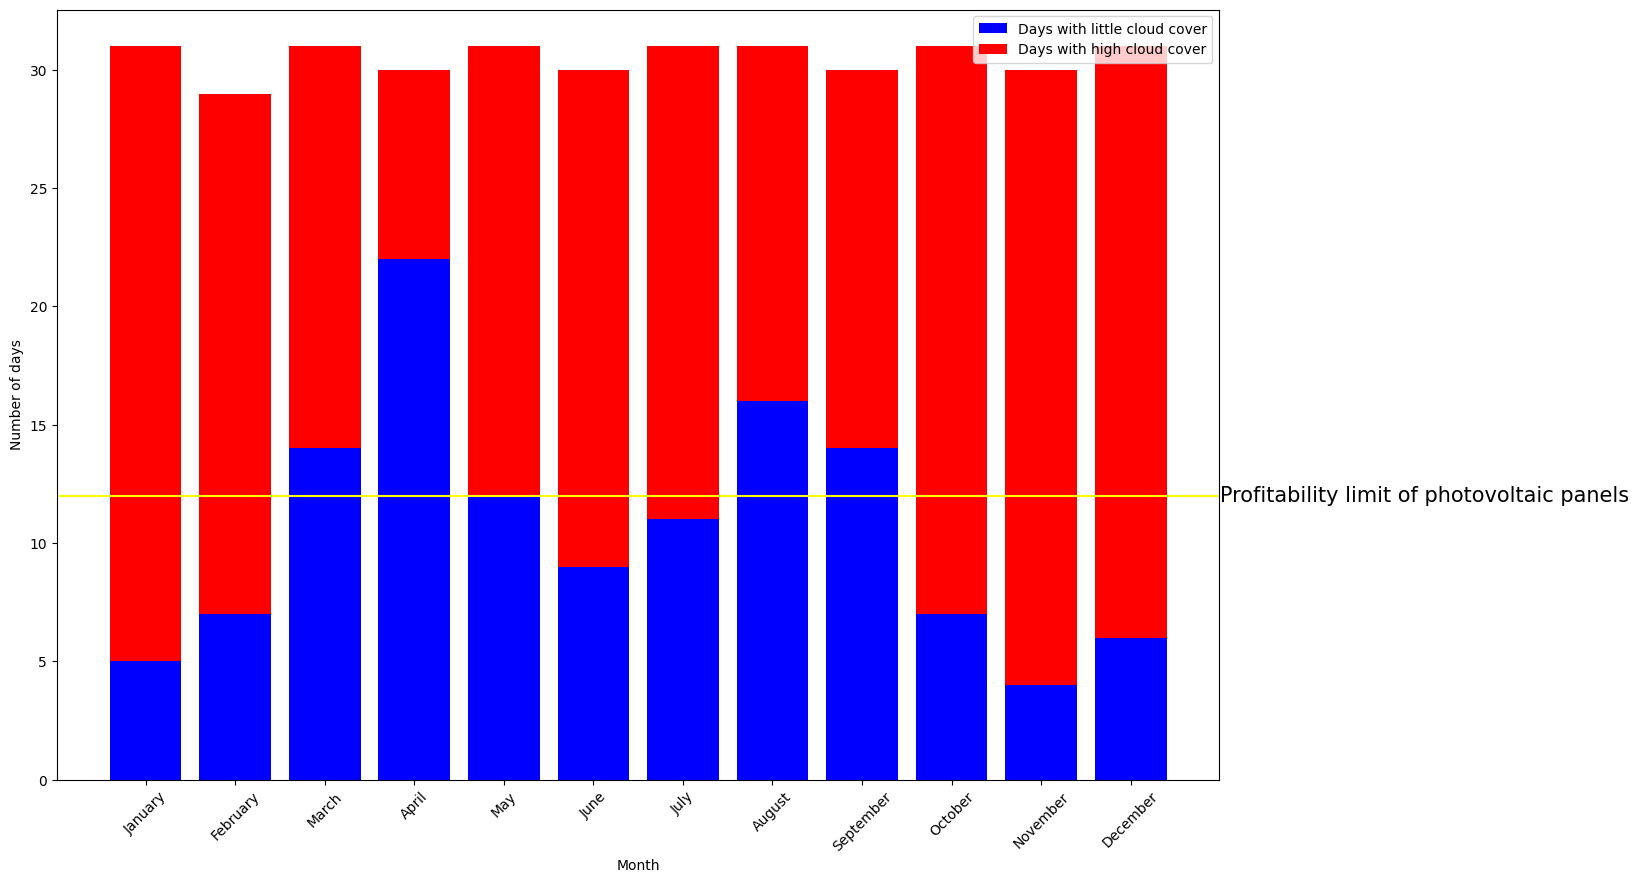

In [12]:
plt.figure(figsize=(15,10))
plt.bar(range(1, 13), s_nice_days_per_month, color='blue', label="Days with little cloud cover")
plt.bar(range(1, 13), s_bad_days_per_month, color='red', bottom=s_nice_days_per_month, label="Days with high cloud cover")
plt.xticks(range(1, 13), months_names, rotation=45)
plt.ylabel('Number of days')
plt.xlabel('Month')
plt.legend()
 
plt.axhline(12, color = "yellow")
plt.text(13, 12, "Profitability limit of photovoltaic panels", fontsize=15, va = 'center')

Text(300, 21, 'Weather breakdown')

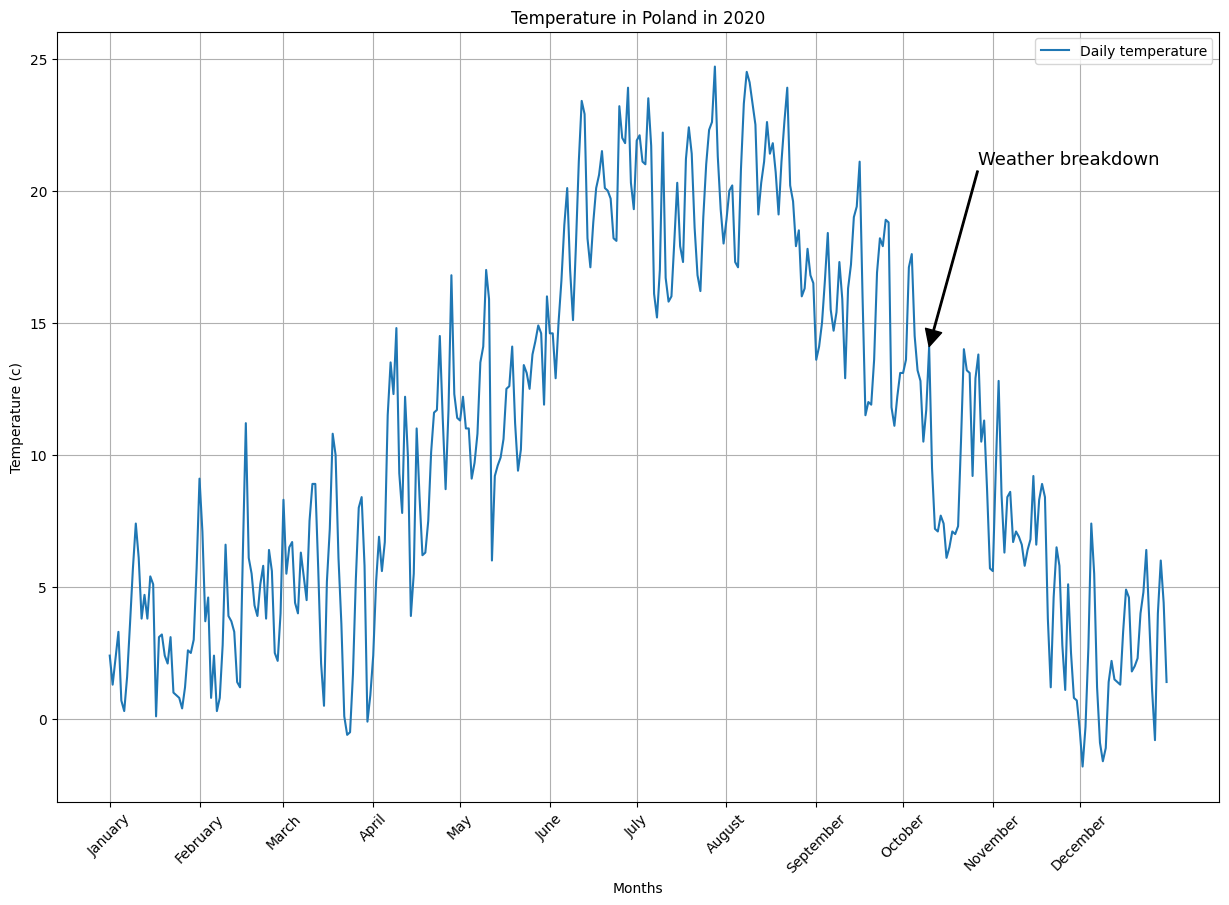

In [13]:
plt.figure(figsize=(15,10))
plt.plot(df['Average daily temperature'], label='Daily temperature')
plt.xticks(months_change, months_names, rotation=45)
plt.ylabel('Temperature (c)')
plt.xlabel('Months')
plt.title('Temperature in Poland in 2020')
plt.legend()
plt.grid()
 
plt.annotate('Weather breakdown', xy=(283, df['Average daily temperature'].iloc[283]), fontsize=13,
             xytext=(
300, 21), arrowprops=dict(facecolor='black', width=1))
# x = 283 (indeks ili vreme)
# y = vrednost temperature u toj tački

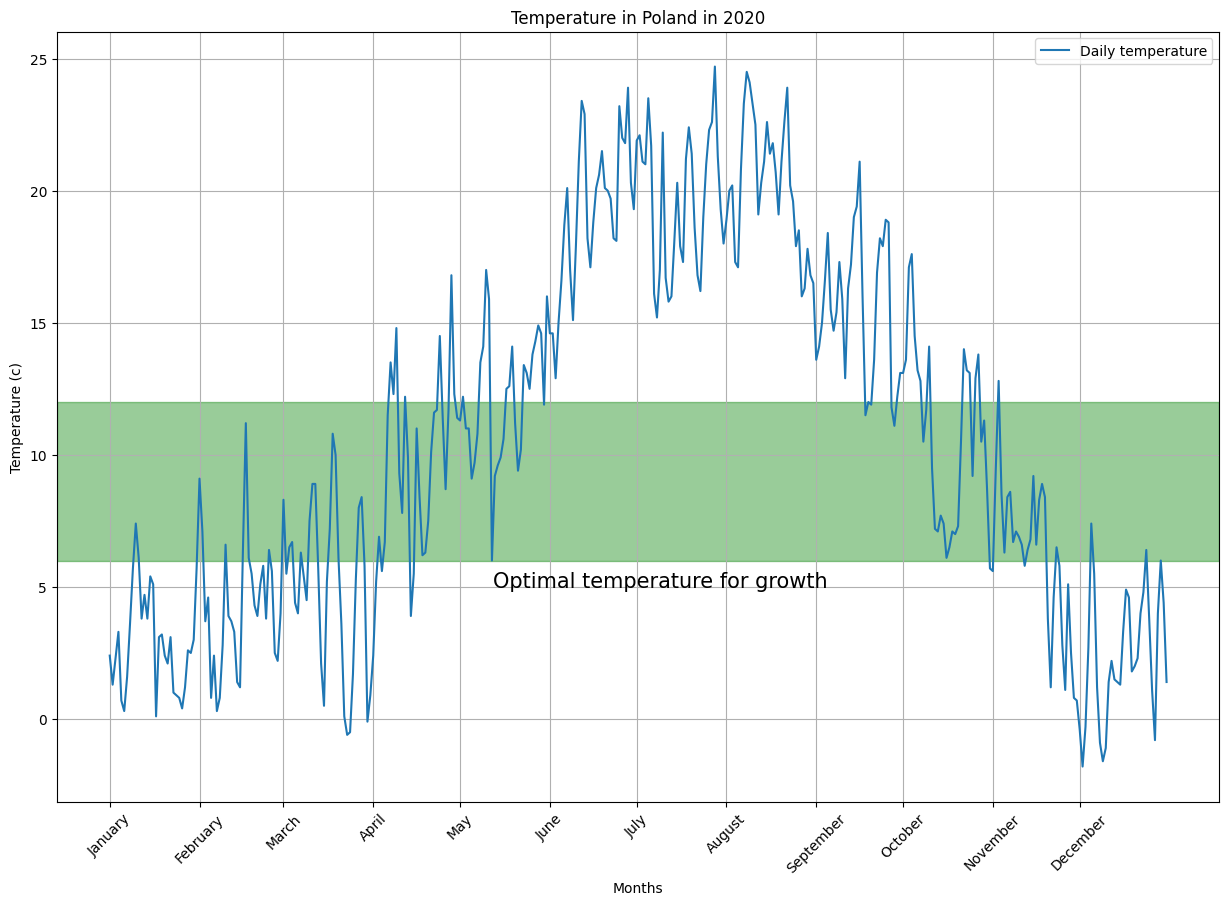

'crta horizontalnu obojenu zonu između:\ny = 6\ny = 12'

In [14]:
plt.figure(figsize=(15,10))
plt.plot(df['Average daily temperature'], label='Daily temperature')
plt.xticks(months_change, months_names, rotation=45)
plt.ylabel('Temperature (c)')
plt.xlabel('Months')
plt.title("Temperature in Poland in 2020")
plt.legend()
plt.grid()
 
plt.axhspan(6, 12, color='green', alpha=0.4)
plt.text(190, 5, "Optimal temperature for growth", fontsize=15, ha = 'center')
plt.show()
'''crta horizontalnu obojenu zonu između:
y = 6
y = 12'''
# alpha=0.4 → providnost (da se vidi graf ispod)

[[[247 247 247]
  [247 247 247]
  [247 247 247]
  ...
  [247 247 247]
  [247 247 247]
  [247 247 247]]

 [[247 247 247]
  [247 247 247]
  [247 247 247]
  ...
  [247 247 247]
  [247 247 247]
  [247 247 247]]

 [[247 247 247]
  [247 247 247]
  [247 247 247]
  ...
  [247 247 247]
  [247 247 247]
  [247 247 247]]

 ...

 [[247 247 247]
  [247 247 247]
  [247 247 247]
  ...
  [247 247 247]
  [247 247 247]
  [247 247 247]]

 [[247 247 247]
  [247 247 247]
  [247 247 247]
  ...
  [247 247 247]
  [247 247 247]
  [247 247 247]]

 [[247 247 247]
  [247 247 247]
  [247 247 247]
  ...
  [247 247 247]
  [247 247 247]
  [247 247 247]]]
[247 247 247 ... 247 247 247]


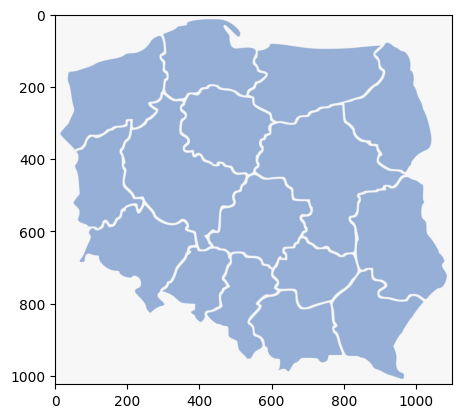

In [15]:
import matplotlib.image as mpimg
 
img = mpimg.imread('./Poland_map.jpg')
plt.imshow(img)
print(img)
print(img.ravel())